## Nucleic Acid Thermodynamics

In this chapter we cover:
- physics of RNA and DNA binding
- computational approaches


### Secondary structure

A DNA or RNA molecule can form bonds with itself or other molecules in the form of base-pairing.

One typically distinguishes between **pseudoknot-free** structures and those with **pseudoknots**.
This can be visualized by arranging a DNA/RNA strand in a circle and marking base-pairs with lines between the bonding nucleotides.
Pseudoknots are crossing base-pairs.
Examples are shown in the figure below.



![Structures without pseudoknot](bp_nopseudoknot.svg){width="340"}

![Structures with pseudoknot](bp_pseudoknot.svg){width="340"}

Base-pairing is a reversible and stochastic process dictated by the rules of thermodynamics.
In particular, different copies of the molecule will probably be in different states and a single molecule will probably change states over time.
The probability of a given secondary structure $s$ to occur in equilibrium is given by

\begin{equation}
P(s) = \frac{1}{Q} e^{- \Delta G(s) / kT}
\end{equation}

where $\Delta G(s)$ is the difference in Gibbs free energy of structure $s$ (usually with respect to the structure without base-pairings), $k$ is the Boltzmann constant, $T$ is the temperature, and $Q$ is the partition function (that is, a normalization term to have all probabilities sum up to $1$).
The secondary structure with the highest probability is usually called the **minimum free energy (MFE) structure**.

The secondary structure can be analyzed with libraries such as the `ViennaRNA` library.
We will use it to return the MFE, the value for $\Delta G(\text{MFE})$, the **ensemble free energy** that is defined as

$$\Delta G_\text{ens} = -kT \ln Q$$

as well as the probability $P(\text{MFE})$ by running the following code:

In [23]:
import RNA
import pint

u = pint.UnitRegistry()
temperature = pint.Quantity(23, u.celsius)

As an example, we will analyze the structure of an RNA sequence next.

In [24]:
# example RNA sequence
sequence = 'GGCUGGUUUCUGCUCUCUAGUUCGCGAGGUGCAAUCUCCUAUC'

md = RNA.md()
md.temperature = temperature.to(u.celsius).magnitude

fc = RNA.fold_compound(sequence, md)
mfe_structure, mfe_energy = fc.mfe()

fc_pf = RNA.fold_compound(sequence, md)
_, ens_free_energy = fc_pf.pf()
prob_mfe = fc_pf.pr_structure(mfe_structure)

print(f"MFE structure : {mfe_structure}")
print(f"MFE ΔG        : {mfe_energy:.4f} kcal/mol")
print(f"Ensemble ΔG   : {ens_free_energy:.4f} kcal/mol")
print(f"P(MFE)        : {prob_mfe:.4f}")

MFE structure : ....((....(((((((........)))).)))....))....
MFE ΔG        : -11.4900 kcal/mol
Ensemble ΔG   : -12.3429 kcal/mol
P(MFE)        : 0.2347


The structure is represented in dot-parenthesis notation. Dots represent unpaired bases, while matching parentheses represent base pairs. For example, `....((((....))))....` represents a hairpin with four base pairs in a stem.

We can see that the MFE structure has a probability of about 23% to occur.

We can also look at the MFE structure graphically:

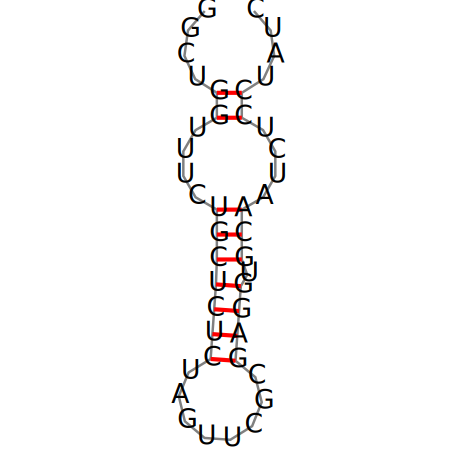

In [25]:
from IPython.display import SVG, display

RNA.svg_rna_plot(sequence, mfe_structure, 'structure_rna.svg')
display(SVG('structure_rna.svg'))

The library also supports DNA. We just have to load the DNA energies:

In [26]:
# example DNA sequence
dna_sequence = 'GGCTGGTTTCTGCTCTCTAGTTCGCGAGGTGCAATCTCCTATC'

# globally load DNA parameters for the Turner 2004 model
RNA.params_load_DNA_Mathews2004()
md = RNA.md()
md.temperature = temperature.to(u.celsius).magnitude

fc = RNA.fold_compound(dna_sequence, md)
mfe_structure, mfe_energy = fc.mfe()

fc_pf = RNA.fold_compound(dna_sequence, md)
_, ens_free_energy = fc_pf.pf()
prob_mfe = fc_pf.pr_structure(mfe_structure)

print(f"MFE structure : {mfe_structure}")
print(f"MFE ΔG        : {mfe_energy:.4f} kcal/mol")
print(f"Ensemble ΔG   : {ens_free_energy:.4f} kcal/mol")
print(f"P(MFE)        : {prob_mfe:.4f}")

MFE structure : .((.(....).))..........((.....))...........
MFE ΔG        : -3.2800 kcal/mol
Ensemble ΔG   : -5.3938 kcal/mol
P(MFE)        : 0.0275


Here, for DNA, the MFE structure occurs in about 28% among all possible structures.
The MFE structure is shown below:

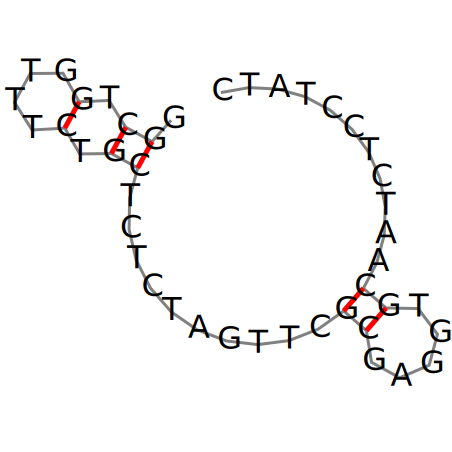

In [27]:
RNA.svg_rna_plot(dna_sequence, mfe_structure, 'structure_dna.svg')
display(SVG('structure_dna.svg'))

We finally reset parameters to RNA for subsequent cells:

In [28]:
RNA.params_load_RNA_Turner2004();

### Partition function, MFE structure

The number $T(N)$ of possible [pseudoknot](https://en.wikipedia.org/wiki/Pseudoknot)-free (no crossing base-pairs) secondary structures with $N$ nucleotides satisfies the recursion 
\begin{equation}
T(N+1) = T(N) + \sum_{k=1}^{N-2} T(k) T(N-k-1)
\end{equation}
and has the asymptotic formula ([Stein and Waterman 1979](https://doi.org/10.1016/0012-365X(79)90033-5)):
\begin{equation}
T(N) \sim \sqrt{\frac{15 + 7\sqrt{5}}{8\pi}} N^{-3/2} \left( \frac{3+\sqrt{5}}{2} \right)^N
\end{equation}
That is, the number of possible secondary structures is exponential in the length of the sequence.
It is nonetheless possible to calculate the MFE structure and the partition function without pseudoknots (no crossing base pairings in the plane) in polynomial time using dynamic programming ([Zuker and Sankoff 1984](https://doi.org/10.1007/BF02459506)).
If pseudoknots are to be taken into account, the computation becomes NP hard.

To show the principle, we now describe a dynamic program to caclulate the partition function ([McCaskill 1990](https://doi.org/10.1002/bip.360290621)).
Denoting by $Q_{i,j}$ the partition function of the subsequence delimited by indices $i$ and $j$ defined as:

$$Q_{i,j} = \sum_{\text{structures } s \text{ on } [i,j]} e^{-\Delta G(s)/kT}$$

the following recursion can be shown to hold:
\begin{equation}
Q_{i,j} = 1 + \sum_{i\leq d < e\leq j} Q_{i,d-1} Q^b_{d,e}
\end{equation}
In this sum, the pair $(d,e)$ denotes the rightmost base pairing (that is, $e$ is maximal).
The term $Q^b(i,j)$ denotes the partition function of the subsequence between $i$ and $j$ with the additional constraint that $i$ and $j$ are base-paired.

\begin{equation}
Q^b_{i,j} = P^\mathrm{hairpin}_{i,j} + \sum_{i<d<e<j} Q^b_{d,e} P^\mathrm{interior}_{i,d,e,j} + Q^m_{i+1,d-1} Q^b_{d,e} P^\mathrm{multi,init}_{i,d,e,j}
\end{equation}

Here, $Q^m_{i,j}$ is the partition function of the subsequence between $i$ and $j$ with the additional constraint that it is inside a multiloop and contains at least one base pair.

\begin{equation}
Q^m_{i,j} = \sum_{i\leq d < e\leq j} Q^b_{d,e} P^\mathrm{multi,end}_{i,d,e,j} + Q^m_{i,d-1} Q^m_{d,e} P^\mathrm{multi,continue}_{i,d,e,j}
\end{equation}

Initially, $Q_{i,i-1} = 1$ and $Q^b_{i,i-1} = Q^m_{i,i-1} = 0$.


### Interacting strands

Until now, we discussed secondary structure of a single nucleic acid strand.
The case of multiple interacting strands is very important, although a bit more difficult ([Dirks, Bois, Schaeffer, Winfree, and Pierce 2007](https://doi.org/10.1137/060651100)).
For the secondary structure, the strands in a complex are linearly ordered around a circle.
The biggest difference is that this multi-strand sequence now has nicks (between strands).
This introduces the need to consider exterior loops between strands.
Mathematically, in the computation of the term $Q^b_{i,j}$ of the partition function, we add a new term that accounts for exterior loops:

\begin{equation}
\sum_{\substack{i\leq c<j\\\text{nick between $c$ and $c+1$}}} Q_{i+1,c} Q_{c+1,j-1}
\end{equation}

The `ViennaRNA` library can carry out these calculations:

In [29]:
seq_a = 'GGCUGGUUUCUGCUCUCUAGUUCGCGAGGUGCAAUCUCCUAUC'
seq_b = 'GTCUGGGAUGCUGGAUACUGAACCUAGAGAGCAGAAACCAGCC'

md = RNA.md()
md.temperature = temperature.to(u.celsius).magnitude

# ViennaRNA co-folds multiple strands by concatenating with '&' at the nick position
seq_ab = seq_a + '&' + seq_b
fc = RNA.fold_compound(seq_ab, md)
mfe_structure, mfe_energy = fc.mfe()
print(f"MFE structure : {mfe_structure}")
print(f"MFE ΔG        : {mfe_energy:.4f} kcal/mol")

fc_pf = RNA.fold_compound(seq_ab, md)
_, ens_free_energy = fc_pf.pf()
bpp = fc_pf.bpp()
print(f"Ensemble ΔG   : {ens_free_energy:.4f} kcal/mol")

n_a, n_b = len(seq_a), len(seq_b)
# bpp is 1-indexed; seq_a occupies 1..n_a, seq_b occupies n_a+1..n_a+n_b
inter_pairs = sum(bpp[i][j] for i in range(1, n_a + 1) for j in range(n_a + 1, n_a + n_b + 1))
print(f"Expected inter-strand base pairs: {inter_pairs:.2f}")

MFE structure : ((((((((((((((((((((((((.(((((...))))))....((((((....))))))...))).))))))))))))))))))))
MFE ΔG        : -61.4000 kcal/mol
Ensemble ΔG   : -62.9517 kcal/mol
Expected inter-strand base pairs: 24.06


## RBS Calculator

One benefit of understanding the properties of RNA molecules is the fact that we can predict the transcription and translation processes to some extent.
A particulatly interesting application is the RBS Calculator ([Salis, Mirsky, and Voigt 2009](https://doi.org/10.1038/nbt.1568), [Salis 2011](https://doi.org/10.1016/B978-0-12-385120-8.00002-4)), which allows the analysis and design of RBS kinetics.
Translation initiation is an important step in the translation process.

<hr>
**License**: © 2025 Matthias Függer and Thomas Nowak. Licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).